#Data Loading & Data Cleaning

In [ ]:
import kagglehub

path = kagglehub.dataset_download("smayanj/netflix-users-database")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-users-database' dataset.
Path to dataset files: /kaggle/input/netflix-users-database


In [ ]:
import os

print(os.listdir(path))

['netflix_users.csv']


In [ ]:
import pandas as pd

file_path = f"{path}/netflix_users.csv"
df = pd.read_csv(file_path)

df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [ ]:
df.shape

(25000, 8)

In [ ]:
df.columns

Index(['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type',
       'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
User_ID,0
Name,0
Age,0
Country,0
Subscription_Type,0
Watch_Time_Hours,0
Favorite_Genre,0
Last_Login,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


#Data Visualization

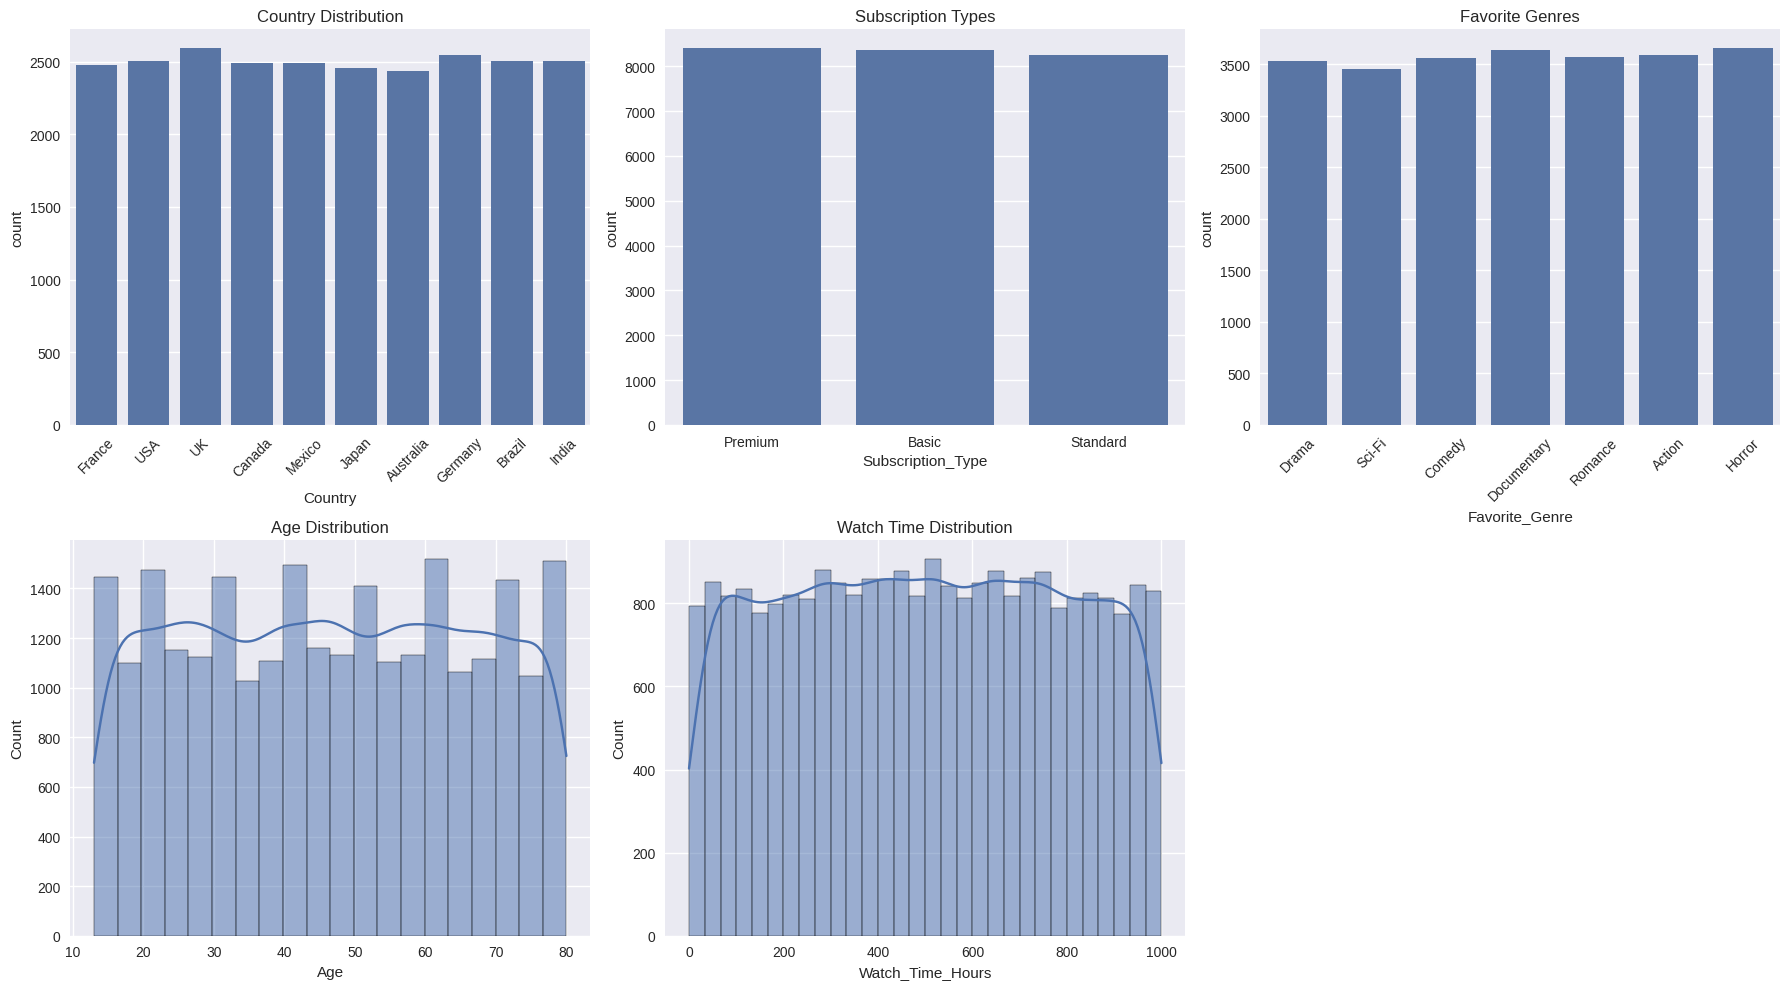

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Country
sns.countplot(x="Country", data=df, ax=axes[0,0])
axes[0,0].set_title("Country Distribution")
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Subscription Type
sns.countplot(x="Subscription_Type", data=df, ax=axes[0,1])
axes[0,1].set_title("Subscription Types")

# 3. Favorite Genre
sns.countplot(x="Favorite_Genre", data=df, ax=axes[0,2])
axes[0,2].set_title("Favorite Genres")
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Age Distribution
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age Distribution")

# 5. Watch Time
sns.histplot(df["Watch_Time_Hours"], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title("Watch Time Distribution")

# Remove empty subplot
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Average watch time per country
df.groupby("Country")["Watch_Time_Hours"].mean().sort_values(ascending=False).head(10)

,Watch_Time_Hours
Country,
Canada,511.423241
Australia,508.207136
France,506.039248
Brazil,503.951806
USA,501.357591
Mexico,496.487858
UK,496.065073
Japan,494.820716
Germany,494.568272


In [ ]:
# Average watch time per subscription type
df.groupby("Subscription_Type")["Watch_Time_Hours"].mean()

,Watch_Time_Hours
Subscription_Type,
Basic,502.994617
Premium,501.409387
Standard,496.949376


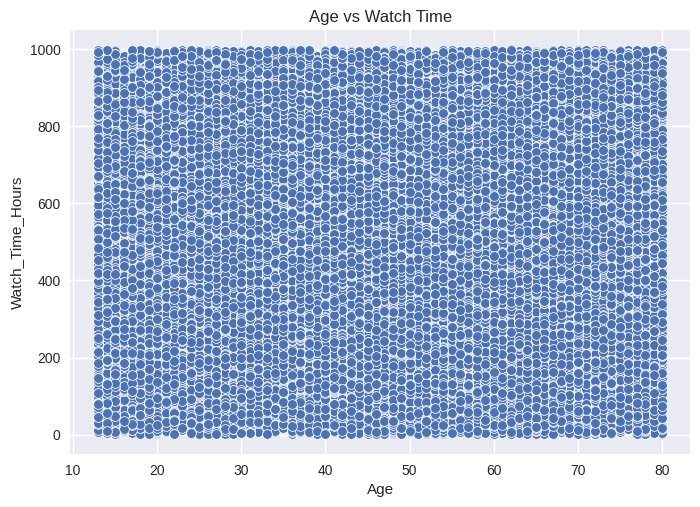

In [ ]:
# Age vs Watch Time relationship
sns.scatterplot(x="Age", y="Watch_Time_Hours", data=df)
plt.title("Age vs Watch Time")
plt.show()

#Feature Engineering & Data Preprocessing

In [ ]:
import pandas as pd

df["Last_Login"] = pd.to_datetime(df["Last_Login"])

# آخر مرة دخل فيها المستخدم   low value --> active user , high value ---> inactive User
reference_date = pd.Timestamp.today().normalize()

df["Days_Since_Last_Login"] = (
    (reference_date - df["Last_Login"]).dt.days.clip(lower=0)
)

In [ ]:
df["Age"].describe()

,Age
count,25000.000000
mean,46.482880
std,19.594861
min,13.000000
25%,29.000000
50%,46.000000
75%,63.000000
max,80.000000


In [ ]:
bins = [1, 13, 29, 46, 63, 80]
labels = ["Child", "Young", "Adult", "MidAge", "Senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
# مين بيستخدم المنصة فعلاً؟
# Watch Time عالي + login قريب → user قوي جدًا
# Watch Time عالي + login بعيد → مش منطقي → inactive heavy user
# Watch Time قليل → casual user
df["Engagement_Score"] = np.log1pdf["Watch_Time_Hours"] / (df["Days_Since_Last_Login"] + 1)

In [ ]:
#بنقسم “سلوك المستخدمين بالتساوي”
df["Watch_Level"] = pd.qcut(
    df["Watch_Time_Hours"],
    q=4,
    labels=["Low", "Medium", "High", "Very_High"]
)

In [ ]:
df["Days_Since_Last_Login"].value_counts().describe()

,count
count,300.000000
mean,83.333333
std,263.504328
min,39.000000
25%,62.750000
50%,68.000000
75%,74.000000
max,4630.000000


In [ ]:
df["Activity_Level"] = pd.qcut(
    df["Days_Since_Last_Login"],
    q=3,
    labels=["Active", "Medium", "Inactive"]
)

In [ ]:
#هل المستخدم بيدفع وبيستخدم؟
# users wasting money
# potential churn users

df["Low_Engagement_Premium"] = (
    (df["Subscription_Type"] == "Premium") &
    (df["Engagement_Score"] < df["Engagement_Score"].median())
)

In [ ]:
df.columns

Index(['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type',
       'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login',
       'Days_Since_Last_Login', 'Age_Group', 'Engagement_Score', 'Watch_Level',
       'Activity_Level', 'Low_Engagement_Premium'],
      dtype='object')

In [ ]:
df[[
    "Age",
    "Age_Group",
    "Watch_Time_Hours",
    "Watch_Level",
    "Days_Since_Last_Login",
    "Activity_Level",
    "Engagement_Score",
    "Low_Engagement_Premium"
]].head()

,Age,Age_Group,Watch_Time_Hours,Watch_Level,Days_Since_Last_Login,Activity_Level,Engagement_Score,Low_Engagement_Premium
0,18,Young,80.26,Low,234,Inactive,0.341532,True
1,23,Young,321.75,Medium,0,Active,321.750000,False
2,60,MidAge,35.89,Low,0,Active,35.890000,False
3,44,Adult,261.56,Medium,282,Inactive,0.924240,True
4,68,Senior,909.30,Very_High,0,Active,909.300000,False


In [ ]:
for col in ["Age_Group", "Watch_Level", "Activity_Level"]:
    print("\n", col)
    print(df[col].value_counts())


 Age_Group
Age_Group
MidAge    6294
Adult     6238
Senior    6175
Young     5954
Child      339
Name: count, dtype: int64

 Watch_Level
Watch_Level
Low          6250
Medium       6250
High         6250
Very_High    6250
Name: count, dtype: int64

 Activity_Level
Activity_Level
Active      8382
Medium      8320
Inactive    8298
Name: count, dtype: int64


In [ ]:
df[["Watch_Time_Hours", "Days_Since_Last_Login", "Engagement_Score"]].head()

,Watch_Time_Hours,Days_Since_Last_Login,Engagement_Score
0,80.26,234,0.341532
1,321.75,0,321.750000
2,35.89,0,35.890000
3,261.56,282,0.924240
4,909.30,0,909.300000


In [ ]:
#drop unimportant columns
df = df.drop(["User_ID", "Name", "Last_Login"], axis=1)

In [ ]:
# encoding categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Country",
        "Subscription_Type",
        "Favorite_Genre",
        "Age_Group",
        "Watch_Level",
        "Activity_Level"
    ],
    drop_first=False
)

In [ ]:
# Boolean Encoding حول الـ bool لـ int
df_encoded["Low_Engagement_Premium"] = df_encoded["Low_Engagement_Premium"].astype(int)

In [ ]:
## Keep numeric only
df_encoded = df_encoded.select_dtypes(include=["int64", "float64", "bool"])

In [ ]:
# scaling encoded features
from sklearn.preprocessing import StandardScaler

df_encoded = df_encoded.astype(float)

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded),
    columns=df_encoded.columns
)

In [ ]:
print(df_scaled.shape)
df_scaled.info()

(25000, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         25000 non-null  float64
 1   Watch_Time_Hours            25000 non-null  float64
 2   Days_Since_Last_Login       25000 non-null  float64
 3   Engagement_Score            25000 non-null  float64
 4   Low_Engagement_Premium      25000 non-null  float64
 5   Country_Australia           25000 non-null  float64
 6   Country_Brazil              25000 non-null  float64
 7   Country_Canada              25000 non-null  float64
 8   Country_France              25000 non-null  float64
 9   Country_Germany             25000 non-null  float64
 10  Country_India               25000 non-null  float64
 11  Country_Japan               25000 non-null  float64
 12  Country_Mexico              25000 non-null  float64
 13  Country_UK         

#Model Architect & Training Engineer

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
input_dim = df_scaled.shape[1]

print("Input Dimension:", input_dim)

Input Dimension: 37


In [ ]:
# latent_dims = [2, 4, 8, 16]

# results = {}

# for dim in latent_dims:

#     # Input
#     input_layer = Input(shape=(input_dim,))

#     # Encoder
#     encoder = Dense(16, activation='relu')(input_layer)
#     encoder = Dense(8, activation='relu')(encoder)

#     # Latent Space
#     latent = Dense(dim, activation='linear')(encoder)

#     # Decoder
#     decoder = Dense(8, activation='relu')(latent)
#     decoder = Dense(16, activation='relu')(decoder)

#     # Output
#     output_layer = Dense(input_dim, activation='linear')(decoder)

#     # Model
#     autoencoder = Model(inputs=input_layer, outputs=output_layer)

#     autoencoder.compile(
#         optimizer='adam',
#         loss='mse'
#     )

#     # Training
#     history = autoencoder.fit(
#         df_scaled,
#         df_scaled,
#         epochs=30,
#         batch_size=32,
#         validation_split=0.2,
#         verbose=0
#     )

#     # Save final validation loss
#     final_val_loss = history.history['val_loss'][-1]

#     results[dim] = final_val_loss

# # Print Results
# for dim, loss in results.items():
#     print(f"Latent Dim = {dim} --> Val Loss = {loss}")

In [ ]:
# Input Layer
input_layer = Input(shape=(input_dim,))

In [ ]:
# Encoder
encoder = Dense(16, activation='relu')(input_layer)
encoder = Dense(8, activation='relu')(encoder)

In [ ]:
# Latent Space
latent = Dense(4, activation='linear', name="latent_space")(encoder)

In [ ]:
# Decoder
decoder = Dense(8, activation='relu')(latent)
decoder = Dense(16, activation='relu')(decoder)

In [ ]:
# Output Layer
output_layer = Dense(input_dim, activation='linear')(decoder)

In [ ]:
# Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# Compile Model
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

# Model Summary
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 37)             │           629 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593 (6.22 KB)

 Trainable params: 1,593 (6.22 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model Training
history = autoencoder.fit(
    df_scaled,
    df_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.8677 - val_loss: 0.7771
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7127 - val_loss: 0.6777
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6425 - val_loss: 0.6332
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6210 - val_loss: 0.6247
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6157 - val_loss: 0.6212
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6123 - val_loss: 0.6179
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6086 - val_loss: 0.6139
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6032 - val_loss: 0.6074
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5944 - val_loss: 0.5969
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5843 - val_loss: 0.5885
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5775 - val_loss: 0.5823
Epoch 12/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

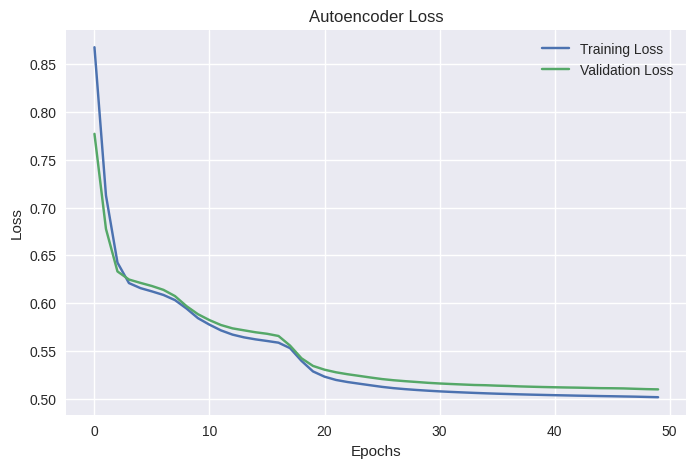

In [ ]:
# Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Autoencoder Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [ ]:
autoencoder.save("full_autoencoder_model.keras")
print("Full Autoencoder Model Saved Successfully!")

Full Autoencoder Model Saved Successfully!


##Deployment, Latent Feature Extraction

In [ ]:
from sklearn.metrics import mean_squared_error
loaded_autoencoder = load_model("full_autoencoder_model.keras")

In [ ]:
# Create Encoder Model
encoder_model = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)

In [ ]:
# Generate Latent Features
latent_features = encoder_model.predict(df_scaled)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
#Convert to DataFrame
latent_df = pd.DataFrame(
    latent_features,
    columns=["Latent1", "Latent2", "Latent3", "Latent4"]
)

latent_df.head()

,Latent1,Latent2,Latent3,Latent4
0,-1.590244,-5.319988,-5.258276,4.021749
1,10.295706,-8.360096,-2.433099,0.571370
2,8.554341,-0.232600,-3.396611,-5.231412
3,-1.342996,-3.818604,-1.865530,5.185905
4,20.159809,-0.475046,0.125558,-9.258867


In [ ]:
print(latent_df.shape)

(25000, 4)


In [ ]:
reconstructed_data = loaded_autoencoder.predict(df_scaled)
mse = mean_squared_error(df_scaled, reconstructed_data)
print(f"Reconstruction MSE: {mse:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Reconstruction MSE: 0.5030


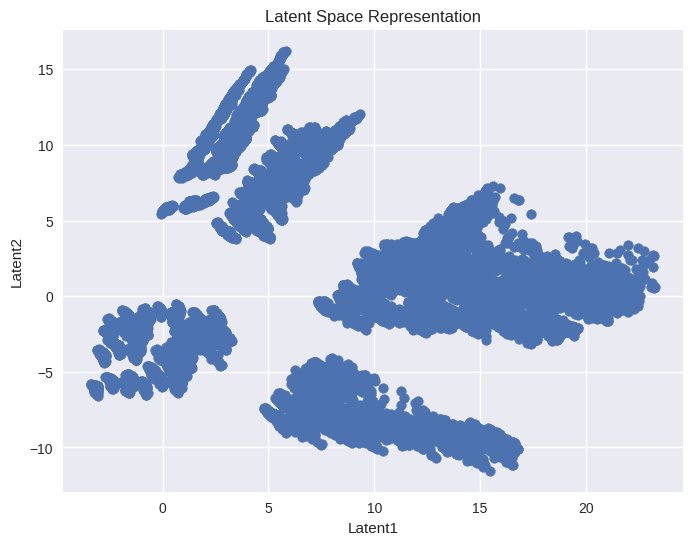

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    latent_df["Latent1"],
    latent_df["Latent2"]
)

plt.title("Latent Space Representation")
plt.xlabel("Latent1")
plt.ylabel("Latent2")

plt.show()

In [ ]:
encoder_model.save("encoder_model.keras")
latent_df.to_csv("latent_features.csv", index=False)

# Clustring Using K-Means

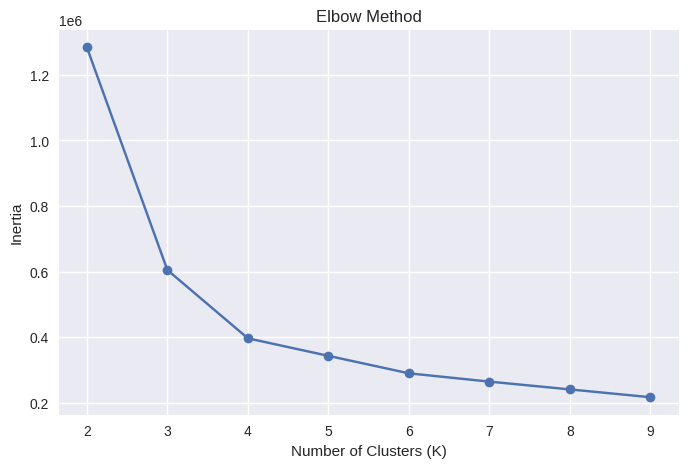

In [ ]:
# Elbow Method (Best K)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

latent_cols = ["Latent1", "Latent2", "Latent3", "Latent4"]
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(latent_df[latent_cols])
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.show()

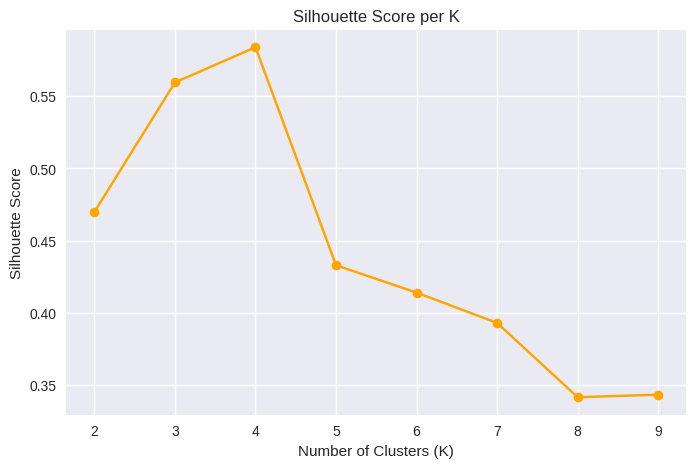

In [ ]:
# Silhouette Score per K
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]])
    score = silhouette_score(latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]], labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker="o", color="orange")
plt.title("Silhouette Score per K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.show()

In [ ]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
latent_df["Cluster"] = kmeans.fit_predict(latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]])

print(latent_df["Cluster"].value_counts())

Cluster
1    10971
0     7304
2     6725
Name: count, dtype: int64


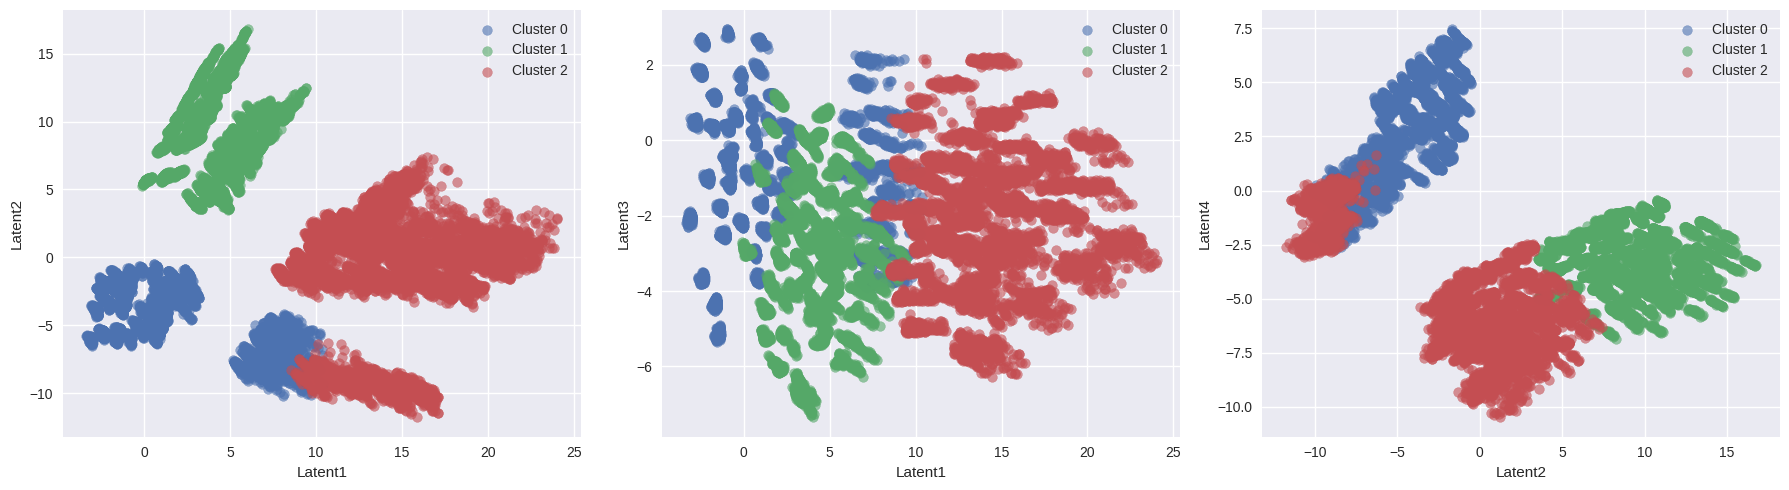

In [ ]:
# Scatter Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [("Latent1", "Latent2"), ("Latent1", "Latent3"), ("Latent2", "Latent4")]

for ax, (x, y) in zip(axes, pairs):
    for cluster in sorted(latent_df["Cluster"].unique()):
        subset = latent_df[latent_df["Cluster"] == cluster]
        ax.scatter(subset[x], subset[y], label=f"Cluster {cluster}", alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cluster Labeling
cluster_names = {
    0: "Active Heavy Watchers",
    1: "Inactive Users",
    2: "Casual Users"
}

latent_df["Cluster_Label"] = latent_df["Cluster"].map(cluster_names)
df_profile["Cluster_Label"] = df_profile["Cluster"].map(cluster_names)

print(latent_df["Cluster_Label"].value_counts())

Cluster_Label
Inactive Users           10971
Active Heavy Watchers     7304
Casual Users              6725
Name: count, dtype: int64


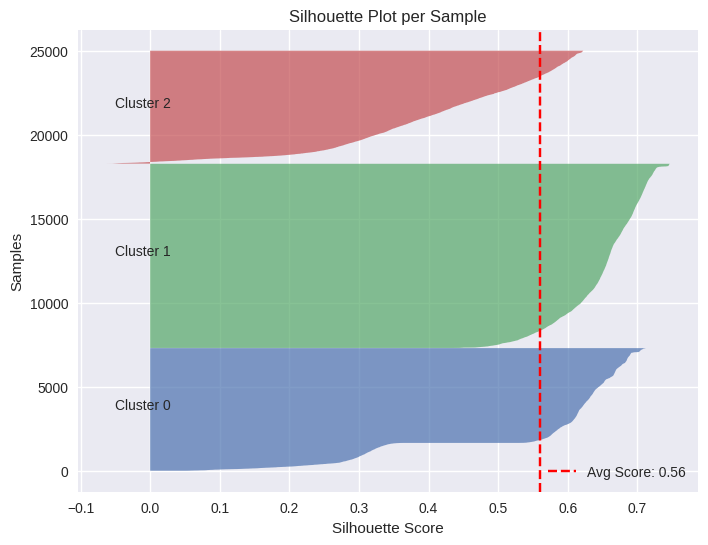

In [ ]:
# Silhouette Score per sample
from sklearn.metrics import silhouette_samples
import numpy as np

sample_scores = silhouette_samples(latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]], latent_df["Cluster"])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for cluster in sorted(latent_df["Cluster"].unique()):
    cluster_scores = sample_scores[latent_df["Cluster"] == cluster]
    cluster_scores.sort()

    size = len(cluster_scores)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores, alpha=0.7)
    ax.text(-0.05, y_lower + size / 2, f"Cluster {cluster}")

    y_lower = y_upper + 10

ax.axvline(x=sample_scores.mean(), color="red", linestyle="--", label=f"Avg Score: {sample_scores.mean():.2f}")
ax.set_title("Silhouette Plot per Sample")
ax.set_xlabel("Silhouette Score")
ax.set_ylabel("Samples")
ax.legend()
plt.show()

# Clustring Using Agglomerative

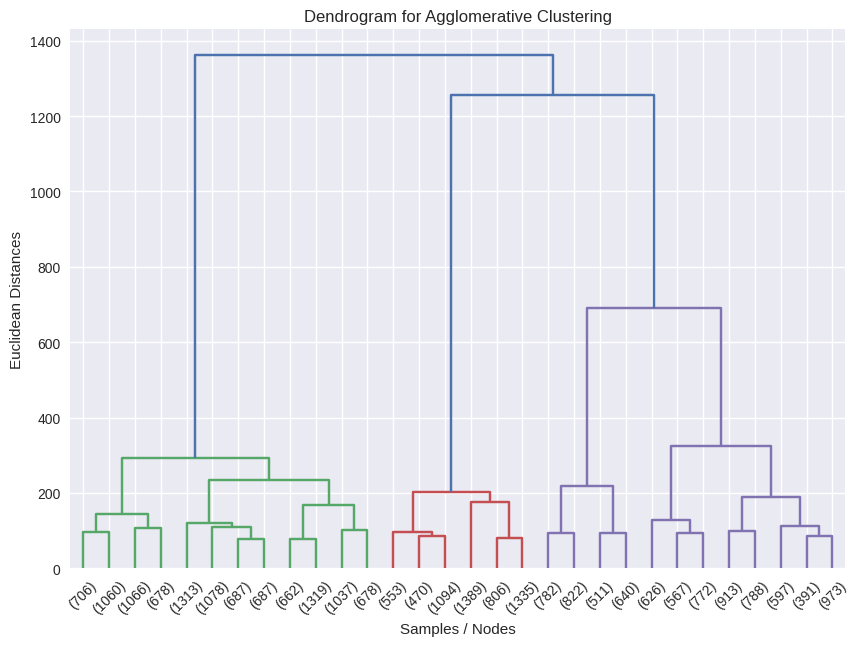

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendrogram for Agglomerative Clustering")

# Compute the linkage matrix using Ward's method
linkage_matrix = sch.linkage(latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]], method='ward')

# Plot the hierarchical tree (truncated to the last 30 merged clusters for clarity)
dendrogram = sch.dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30
)

plt.xlabel("Samples / Nodes")
plt.ylabel("Euclidean Distances")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Initialize Agglomerative Clustering with 3 clusters to match K-Means configuration
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# Fit the model and predict cluster labels on latent features
latent_df["Agg_Cluster"] = agg_clustering.fit_predict(latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]])

print("Distribution of Agglomerative Clusters:")
print(latent_df["Agg_Cluster"].value_counts())

Distribution of Agglomerative Clusters:
Agg_Cluster
1    10971
0     8382
2     5647
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for Agglomerative Clustering
agg_sil_score = silhouette_score(
    latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]],
    latent_df["Agg_Cluster"]
)

print(f"Agglomerative Clustering Silhouette Score: {agg_sil_score:.4f}")

Agglomerative Clustering Silhouette Score: 0.5494


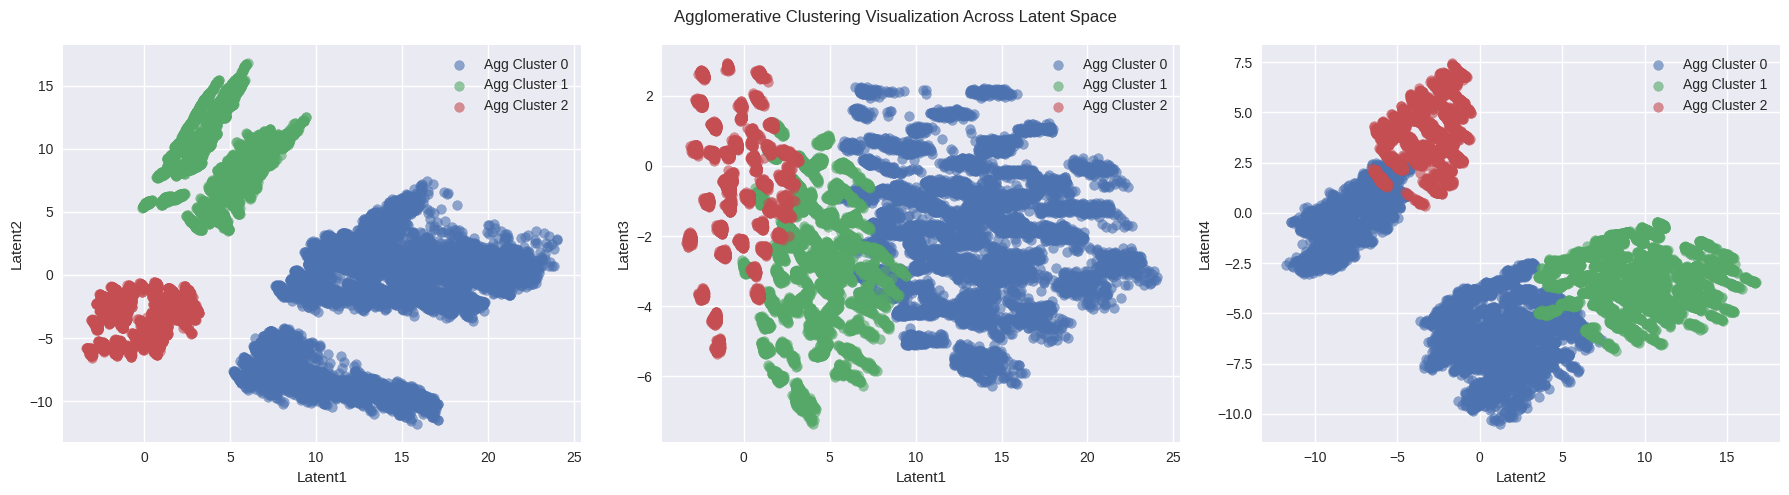

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [("Latent1", "Latent2"), ("Latent1", "Latent3"), ("Latent2", "Latent4")]

# Scatter plot for each pair of latent features colored by Agglomerative cluster labels
for ax, (x, y) in zip(axes, pairs):
    for cluster in sorted(latent_df["Agg_Cluster"].unique()):
        subset = latent_df[latent_df["Agg_Cluster"] == cluster]
        ax.scatter(subset[x], subset[y], label=f"Agg Cluster {cluster}", alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()

plt.suptitle("Agglomerative Clustering Visualization Across Latent Space")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import silhouette_score

# Extract the Silhouette Score for the previously trained K-Means model (K=3)
kmeans_sil_score = silhouette_score(
    latent_df[["Latent1", "Latent2", "Latent3", "Latent4"]],
    latent_df["Cluster"]
)

# Structure the final evaluation matrix data
comparison_data = {
    "Metric / Feature": ["Number of Clusters", "Silhouette Score", "Algorithm Type"],
    "K-Means": [3, f"{kmeans_sil_score:.4f}", "Centroid-based (Partitioning)"],
    "Agglomerative": [3, f"{agg_sil_score:.4f}", "Connectivity-based (Hierarchical)"]
}

# Generate the comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)

print("="*30 + " FINAL MODEL COMPARISON " + "="*30)
display(comparison_df)
print("="*84)

============================== FINAL MODEL COMPARISON ==============================


,Metric / Feature,K-Means,Agglomerative
0,Number of Clusters,3,3
1,Silhouette Score,0.5597,0.5494
2,Algorithm Type,Centroid-based (Partitioning),Connectivity-based (Hierarchical)
